# Pose-Based Human Action Recognition Project


In [1]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import os

# Data Loading

In [2]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

!pip install -q mpose

  Preparing metadata (setup.py) ... done


In [4]:
cache_dir = '/content/drive/MyDrive/APS360/Project/data'
os.makedirs(cache_dir, exist_ok=True)
npz_path = os.path.join(cache_dir, 'mpose_posenet_split1.npz')

if os.path.exists(npz_path):
    z = np.load(npz_path)
    X_train, y_train, X_test, y_test = z['X_train'], z['y_train'], z['X_test'], z['y_test']
    print('loaded from Drive cache')
else:
    import mpose
    dataset = mpose.MPOSE(pose_extractor='posenet', split=1)   # raw keypoints, do my own data preprocessing
    dataset.get_info()
    X_train, y_train, X_test, y_test = dataset.get_data()
    np.savez_compressed(npz_path,
                        X_train=X_train, y_train=y_train,
                        X_test=X_test, y_test=y_test)
    print('downloaded + cached to Drive')

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)


loaded from Drive cache
(12562, 30, 17, 3) (12562,) (2867, 30, 17, 3) (2867,)


In [ ]:
# sanity check before data prepocessing

# check the labels in the dataset
print("y dtype:", y_train.dtype)
print("unique labels:", np.unique(y_train))
print("num classes:", len(np.unique(y_train)))
print("first 10:", y_train[:10])

# check the percentage of each class
vals, counts = np.unique(y_train, return_counts=True)
print("\nclass distribution (train):")
for v, c in zip(vals, counts):
    print(f"  class {v}: {c:5d}  ({100*c/len(y_train):.1f}%)")
print(f"imbalance ratio (max/min): {counts.max()/counts.min():.1f}x")

# check the value range per channel, needed for sample normalization
for i, name in enumerate(['x', 'y', 'conf']):
    ch = X_train[..., i]
    print(f"\n{name}: min={ch.min():.3f}  max={ch.max():.3f}  mean={ch.mean():.3f}")


y dtype: int64
unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
num classes: 20
first 10: [13 13 13 13 13 13 13 13 13 13]

class distribution (train):
  class 0:   426  (3.4%)
  class 1:   199  (1.6%)
  class 2:   288  (2.3%)
  class 3:   241  (1.9%)
  class 4:   298  (2.4%)
  class 5:   241  (1.9%)
  class 6:   227  (1.8%)
  class 7:  1872  (14.9%)
  class 8:  1070  (8.5%)
  class 9:  1537  (12.2%)
  class 10:   300  (2.4%)
  class 11:   419  (3.3%)
  class 12:   197  (1.6%)
  class 13:   369  (2.9%)
  class 14:  1441  (11.5%)
  class 15:  1826  (14.5%)
  class 16:   550  (4.4%)
  class 17:   204  (1.6%)
  class 18:   243  (1.9%)
  class 19:   614  (4.9%)
imbalance ratio (max/min): 9.5x

x: min=0.000  max=416.000  mean=200.448

y: min=0.000  max=288.000  mean=117.859

conf: min=0.000  max=0.997  mean=0.806


# Data Preprocessing

In [5]:

# keypoint indices
lhip, rhip, lshoulder, rshoulder = 11, 12, 5, 6
conf_thrhold= 0.2

def preprocess(X):
    """
    X: (N, 30, 17, 3) raw pixel keypoints (x, y, conf)
    -> (N, 30, 51) normalized + cleaned, flattened per frame
    """
    X = X.astype(np.float32).copy()   # make copy so not touch the original source data
    xy   = X[..., :2]    # (N,30,17,2)
    conf = X[..., 2:3]    # (N,30,17,1)

    # reference points, computed per frame
    mid_hip = (xy[:, :, lhip] + xy[:, :, rhip]) / 2          # (N,30,2)
    mid_sho = (xy[:, :, lshoulder] + xy[:, :, rshoulder]) / 2   # (N,30,2)
    torso   = np.linalg.norm(mid_sho - mid_hip, axis=-1)       # (N,30)
    torso   = np.clip(torso, 0.001, None)[..., None, None]      # avoid divide-by-zero

    # normalization
    # center at mid-hip, scale by torso length
    xy = (xy - mid_hip[:, :, None, :]) / torso

    # zero out low-confidence joints (position and confidence flag)
    bad = conf < conf_thrhold
    xy   = np.where(bad, 0.0, xy)
    conf = np.where(bad, 0.0, conf)

    #recombine + flatten
    X = np.concatenate([xy, conf], axis=-1)   # (N,30,17,3)
    return X.reshape(X.shape[0], X.shape[1], -1)  # (N,30,51)


In [7]:
X_train_p = preprocess(X_train)
X_test_p  = preprocess(X_test)
# sanity check; expect (12562, 30, 51) (2867, 30, 51)
print(X_train_p.shape, X_test_p.shape)

(12562, 30, 51) (2867, 30, 51)


# Data Spliting

In [8]:
from sklearn.model_selection import train_test_split

seed = 66

# split validation set out of training set
# use stratify to keep class proportions
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_p, y_train, test_size=0.176, stratify=y_train, random_state=seed)
print("train:", X_tr.shape, "val:", X_val.shape, "test:", X_test_p.shape)

# tensors -> dataLoaders
def get_data_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(torch.as_tensor(X, dtype=torch.float32),
                       torch.as_tensor(y, dtype=torch.long))   #long for CrossEntropyLoss
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = get_data_loader(X_tr,     y_tr,  batch_size=64,  shuffle=True)   # shuffle train
val_loader   = get_data_loader(X_val,    y_val, batch_size=256, shuffle=False)
test_loader  = get_data_loader(X_test_p, y_test, batch_size=256, shuffle=False)

# inverse-frequency class weights for the imbalanced loss
# used to balance different classes
counts = np.bincount(y_tr, minlength=20)
class_weights = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float32)
print(f"class weights range: {class_weights.min().item():.3f} -> {class_weights.max().item():.3f}")


train: (10351, 30, 51) val: (2211, 30, 51) test: (2867, 30, 51)
class weights range: 0.335 -> 3.195


# Base line model


In [10]:
from sklearn.metrics import accuracy_score, f1_score

1 Majority-class Baseline


> Prove that the model is learning






In [ ]:

#get the most frequent class in the traning data set
majority_class = np.bincount(y_tr).argmax()
print("most frequent training class:", majority_class)

#let the baseline predict the majority class
y_pred = np.full_like(y_val, fill_value=majority_class)

# score it
acc = accuracy_score(y_val, y_pred)
macro_f1 = f1_score(y_val, y_pred, average='macro')
print(f"Majority-class baseline: accuracy: {acc:.3f}   macro-F1: {macro_f1:.3f}")


most frequent training class: 7
Majority-class baseline: accuracy: 0.149   macro-F1: 0.013


Helper functions

In [9]:
import copy

def evaluate(model, loader, criterion, device=('cuda' if torch.cuda.is_available() else 'cpu')):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad(): # no gradient tracking for evaluation
      for X, y in loader:
          X, y = X.to(device), y.to(device)
          #evaluate on data set
          outputs = model(X)
          loss = criterion(outputs, y)
          pred = outputs.argmax(dim=1).cpu()
          total_loss += loss.item()
          all_preds.append(pred)
          all_labels.append(y.cpu())
    model.train()
    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return (total_loss / len(loader),
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='macro'))

def train(model, train_loader, val_loader, class_weights, device=('cuda' if torch.cuda.is_available() else 'cpu'),
          epochs=60, lr=0.001, tolerance = 10):
    model.to(device)

    # loss function and optimizer
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []} # place holder for error and loss
    best_f1, best_state, no_improve = -1.0, None, 0      # track best F1 score, best set of weights and no improvements count

    for epoch in range(epochs):
        running = 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            # forward pass, loss calculation, backward pass, update weights
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            running += loss.item()
           #  stats
        train_loss = running / len(train_loader)

        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)

        # append the training data after each epoch
        for k, v in zip(history, [train_loss, val_loss, val_acc, val_f1]):
            history[k].append(v)
        print(f"epoch {epoch+1:2d}  train_loss {train_loss:.3f}  "
              f"val_loss {val_loss:.3f}  acc {val_acc:.3f}  macroF1 {val_f1:.3f}")

        if val_f1 > best_f1:                       # early stopping on val macro-F1
            best_f1, best_state, no_improve = val_f1, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= tolerance:
                print(f"early stop @ epoch {epoch+1} (best macroF1 {best_f1:.3f})")
                break

    model.load_state_dict(best_state)              # restore best weights
    return history


def plot_training_curve(history, title=""):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # train vs validation loss
    ax1.plot(epochs, history['train_loss'], label="Train")
    ax1.plot(epochs, history['val_loss'],   label="Validation")
    ax1.set_title(f"{title} — Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(loc='best')

    # validation accuracy and macro_f1
    ax2.plot(epochs, history['val_acc'], label="Val accuracy")
    ax2.plot(epochs, history['val_f1'],  label="Val macro-F1")
    ax2.set_title(f"{title} — Validation metrics"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
    ax2.legend(loc='best')

    plt.tight_layout()
    plt.show()

def get_predictions(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
      for X, y in loader:
          y_pred.append(model(X.to(device)).argmax(1).cpu())
          y_true.append(y)
    model.train()
    return torch.cat(y_true).numpy(), torch.cat(y_pred).numpy()

2 MLP baseline bodel (average pose recognition)


> compare with the RNN model which takes a 30 frame input



In [ ]:
class AvgPoseMLP(nn.Module):
    def __init__(self, in_dim=51, n_classes=20, p_drop=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(128, 64),     nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):            # (batch, 30, 51)
        x = x.mean(dim=1)            # average over the 30 frames (batch, 51)
        return self.net(x)           # logits (batch, 20)




Train average MLP model

> Quantitative result












epoch  1  train_loss 2.874  val_loss 2.577  acc 0.307  macroF1 0.141
epoch  2  train_loss 2.465  val_loss 2.201  acc 0.423  macroF1 0.241
epoch  3  train_loss 2.265  val_loss 2.082  acc 0.430  macroF1 0.270
epoch  4  train_loss 2.170  val_loss 2.010  acc 0.458  macroF1 0.288
epoch  5  train_loss 2.104  val_loss 1.926  acc 0.480  macroF1 0.341
epoch  6  train_loss 2.053  val_loss 1.885  acc 0.494  macroF1 0.337
epoch  7  train_loss 2.019  val_loss 1.838  acc 0.496  macroF1 0.352
epoch  8  train_loss 1.968  val_loss 1.833  acc 0.499  macroF1 0.372
epoch  9  train_loss 1.947  val_loss 1.776  acc 0.492  macroF1 0.373
epoch 10  train_loss 1.913  val_loss 1.741  acc 0.499  macroF1 0.384
epoch 11  train_loss 1.878  val_loss 1.733  acc 0.478  macroF1 0.364
epoch 12  train_loss 1.848  val_loss 1.677  acc 0.509  macroF1 0.404
epoch 13  train_loss 1.830  val_loss 1.662  acc 0.517  macroF1 0.416
epoch 14  train_loss 1.818  val_loss 1.659  acc 0.515  macroF1 0.409
epoch 15  train_loss 1.787  val_lo

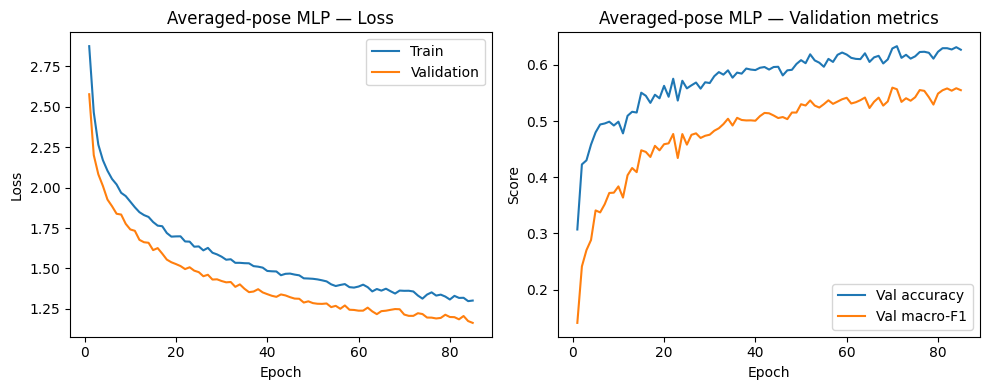

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(66)
mlp = AvgPoseMLP()
history_mlp = train(mlp, train_loader, val_loader, class_weights, device, epochs = 100, tolerance = 15)

plot_training_curve(history_mlp, title="Averaged-pose MLP")



> Save check point on the drive to avoid rerun



In [ ]:
checkpoint_dir = '/content/drive/MyDrive/APS360/Project/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Save the best weights
torch.save(mlp.state_dict(), f"{checkpoint_dir}/mlp_baseline.pt")







> Qualitative result







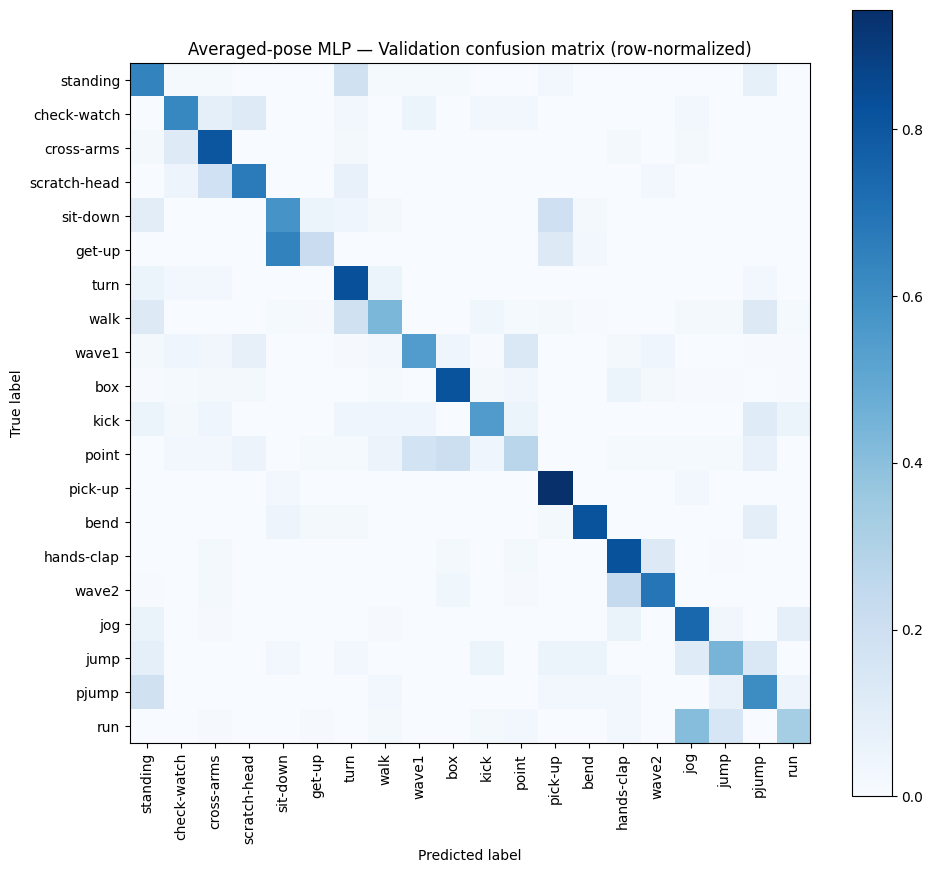

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ACTION_NAMES = ['standing', 'check-watch', 'cross-arms', 'scratch-head', 'sit-down',
                'get-up', 'turn', 'walk', 'wave1', 'box', 'kick', 'point', 'pick-up',
                'bend', 'hands-clap', 'wave2', 'jog', 'jump', 'pjump', 'run']

#predictions on the validation set
y_true, y_pred = get_predictions(mlp, val_loader, device)

#row-normalized confusion matrix (each true-class row sums to 1)
cm = confusion_matrix(y_true, y_pred, normalize='true')

#plot the heatmap
fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay(cm, display_labels=ACTION_NAMES).plot(
    ax=ax, cmap='Blues', include_values=False, colorbar=True, xticks_rotation='vertical')
ax.set_title("Averaged-pose MLP — Validation confusion matrix (row-normalized)")
plt.tight_layout(); plt.show()


In [ ]:
off = cm.copy()                              # cm = your row-normalized confusion matrix
np.fill_diagonal(off, 0.0)                   # ignore correct predictions
top = np.argsort(off, axis=None)[::-1][:10]  # 10 largest off-diagonal entries
for idx in top:
    i, j = np.unravel_index(idx, off.shape)
    print(f"{ACTION_NAMES[i]:>12} (true) -> {ACTION_NAMES[j]:<12} (pred):  {off[i, j]:.2f}")


      get-up (true) -> sit-down     (pred):  0.64
         run (true) -> jog          (pred):  0.41
       wave2 (true) -> hands-clap   (pred):  0.24
       point (true) -> box          (pred):  0.20
    sit-down (true) -> pick-up      (pred):  0.19
scratch-head (true) -> cross-arms   (pred):  0.19
    standing (true) -> turn         (pred):  0.19
       pjump (true) -> standing     (pred):  0.19
        walk (true) -> turn         (pred):  0.19
       point (true) -> wave1        (pred):  0.18


# Primary Model (LSTM)

In [11]:
class PoseRNN(nn.Module):
    def __init__(self, in_dim=51, hidden=128, num_layers=1, n_classes=20, p_drop=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=in_dim, hidden_size=hidden,
                            num_layers=num_layers, batch_first=True,
                            dropout=p_drop if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(p_drop)
        self.fc = nn.Linear(hidden, n_classes)

    def forward(self, x):                  # x: (batch, 30, 51)
        out, (h_n, c_n) = self.lstm(x)     # h_n: (num_layers, batch, hidden)
        last = h_n[-1]                     # (batch, hidden) — final hidden state, top layer
        return self.fc(self.dropout(last)) # logits (batch, 20)




> # train primary model



epoch  1  train_loss 2.520  val_loss 2.143  acc 0.413  macroF1 0.283
epoch  2  train_loss 2.029  val_loss 1.884  acc 0.487  macroF1 0.358
epoch  3  train_loss 1.896  val_loss 1.828  acc 0.449  macroF1 0.343
epoch  4  train_loss 1.760  val_loss 1.695  acc 0.457  macroF1 0.391
epoch  5  train_loss 1.650  val_loss 1.630  acc 0.507  macroF1 0.408
epoch  6  train_loss 1.590  val_loss 1.525  acc 0.523  macroF1 0.442
epoch  7  train_loss 1.450  val_loss 1.409  acc 0.583  macroF1 0.485
epoch  8  train_loss 1.390  val_loss 1.345  acc 0.609  macroF1 0.497
epoch  9  train_loss 1.302  val_loss 1.335  acc 0.585  macroF1 0.506
epoch 10  train_loss 1.224  val_loss 1.243  acc 0.627  macroF1 0.535
epoch 11  train_loss 1.190  val_loss 1.153  acc 0.622  macroF1 0.535
epoch 12  train_loss 1.123  val_loss 1.224  acc 0.565  macroF1 0.501
epoch 13  train_loss 1.080  val_loss 1.147  acc 0.659  macroF1 0.566
epoch 14  train_loss 1.013  val_loss 1.106  acc 0.687  macroF1 0.598
epoch 15  train_loss 1.020  val_lo

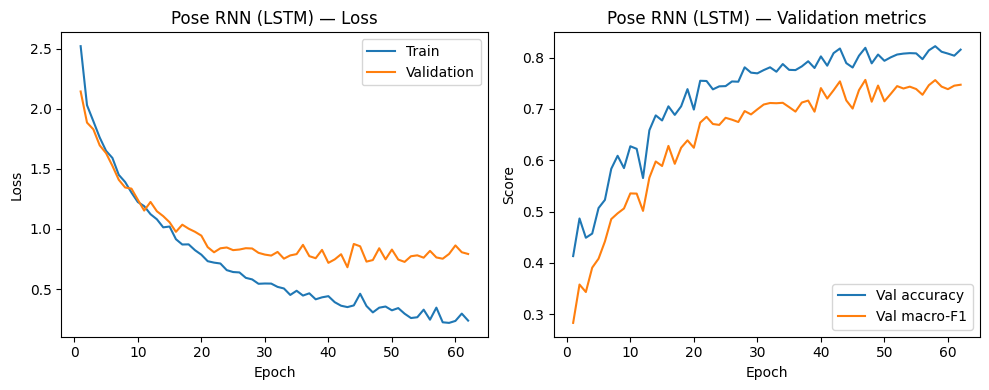

In [14]:
pose_net = PoseRNN()
history_rnn = train(pose_net, train_loader, val_loader, class_weights,
                    epochs=100, tolerance=15)

plot_training_curve(history_rnn, title="Pose RNN (LSTM)")